Preprocessing complete
Shape: (891, 10)

DT depth=3: 0.8058
DT depth=4: 0.8059
DT depth=5: 0.8047
DT depth=6: 0.8148

Best DT: depth=6, score=0.8148
Decision tree saved

Decision Tree 5-fold CV:
Scores: [0.79329609 0.79775281 0.85393258 0.7752809  0.85393258]
Mean: 0.8148
Std: 0.0328

RF n=50, d=5: 0.8115
RF n=100, d=7: 0.8182
RF n=100, d=10: 0.8306
RF n=200, d=7: 0.8171

Best RF: score=0.8306

Random Forest 5-fold CV:
Scores: [0.79888268 0.79775281 0.87640449 0.82022472 0.85955056]
Mean: 0.8306
Std: 0.0320

COMPARISON
Decision Tree: 0.8148 ± 0.0328
Random Forest: 0.8306 ± 0.0320

Random Forest is better
Improvement: 0.0157

Comparison plot saved

Done!


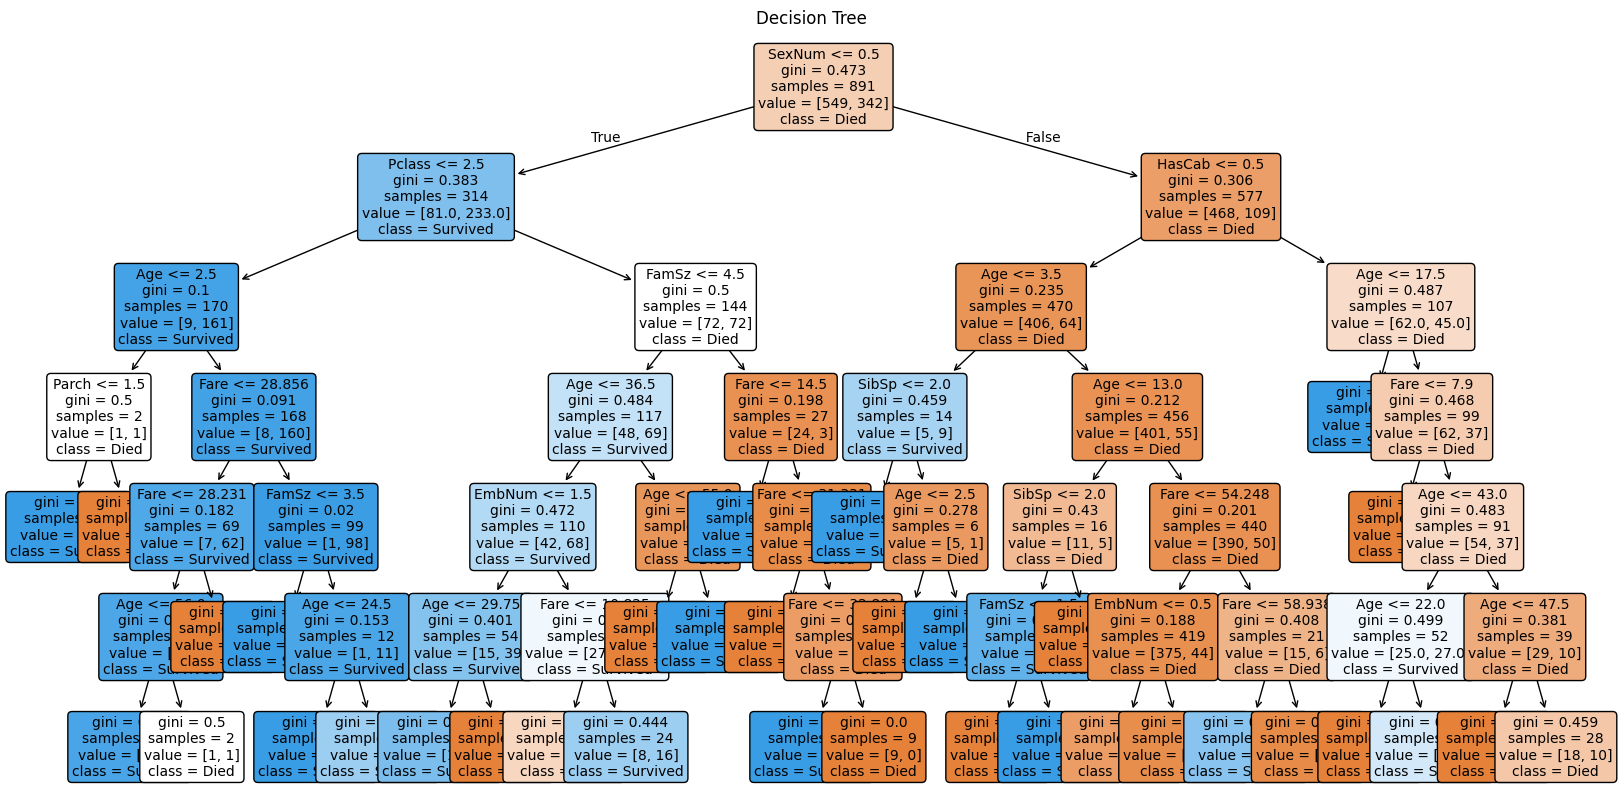

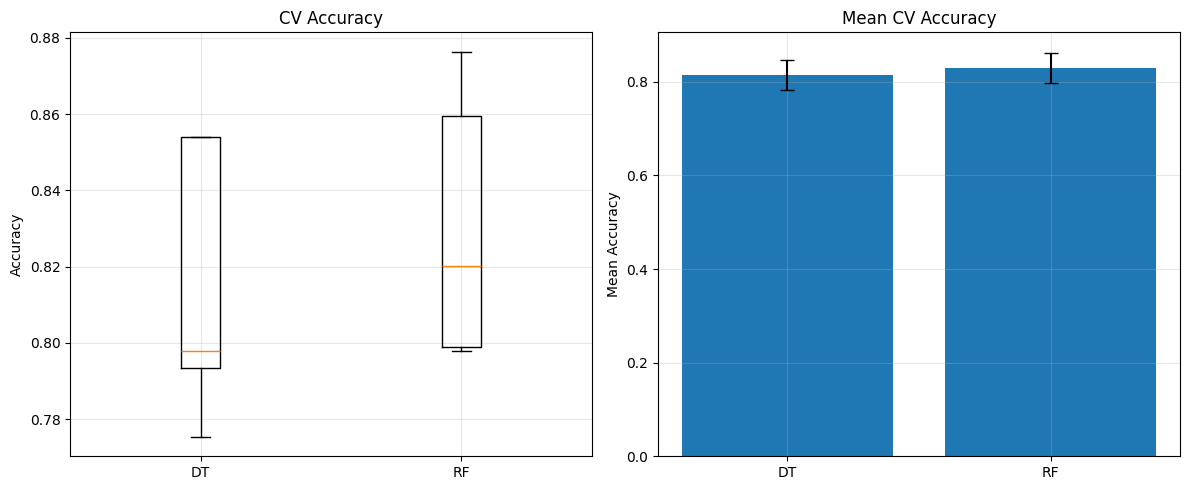

In [1]:
#Task 1
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

np.random.seed(42)

df = pd.read_csv('train.csv')

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

df['HasCab'] = df['Cabin'].notna().astype(int)
df['FamSz'] = df['SibSp'] + df['Parch'] + 1
df['Alone'] = (df['FamSz'] == 1).astype(int)

le_sex = LabelEncoder()
df['SexNum'] = le_sex.fit_transform(df['Sex'])

le_emb = LabelEncoder()
df['EmbNum'] = le_emb.fit_transform(df['Embarked'])

feat = ['Pclass', 'SexNum', 'Age', 'SibSp', 'Parch', 'Fare', 'EmbNum', 'HasCab', 'FamSz', 'Alone']
X = df[feat]
y = df['Survived']

print("Preprocessing complete")
print(f"Shape: {X.shape}")

dt1 = DecisionTreeClassifier(max_depth=3, min_samples_split=20, random_state=42)
dt1.fit(X, y)

dt2 = DecisionTreeClassifier(max_depth=4, min_samples_split=10, random_state=42)
dt2.fit(X, y)

dt3 = DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=42)
dt3.fit(X, y)

dt4 = DecisionTreeClassifier(max_depth=6, min_samples_split=2, random_state=42)
dt4.fit(X, y)

s1 = cross_val_score(dt1, X, y, cv=5).mean()
s2 = cross_val_score(dt2, X, y, cv=5).mean()
s3 = cross_val_score(dt3, X, y, cv=5).mean()
s4 = cross_val_score(dt4, X, y, cv=5).mean()

print(f"\nDT depth=3: {s1:.4f}")
print(f"DT depth=4: {s2:.4f}")
print(f"DT depth=5: {s3:.4f}")
print(f"DT depth=6: {s4:.4f}")

scores = [s1, s2, s3, s4]
models = [dt1, dt2, dt3, dt4]
best_idx = scores.index(max(scores))
best_dt = models[best_idx]

print(f"\nBest DT: depth={[3,4,5,6][best_idx]}, score={scores[best_idx]:.4f}")

plt.figure(figsize=(20, 10))
plot_tree(best_dt, feature_names=feat, class_names=['Died', 'Survived'], 
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree')
plt.savefig('dt_plot.png', dpi=300, bbox_inches='tight')
print("Decision tree saved")

dt_cv = cross_val_score(best_dt, X, y, cv=5)
print(f"\nDecision Tree 5-fold CV:")
print(f"Scores: {dt_cv}")
print(f"Mean: {dt_cv.mean():.4f}")
print(f"Std: {dt_cv.std():.4f}")

rf1 = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf1.fit(X, y)

rf2 = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
rf2.fit(X, y)

rf3 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf3.fit(X, y)

rf4 = RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42)
rf4.fit(X, y)

rs1 = cross_val_score(rf1, X, y, cv=5).mean()
rs2 = cross_val_score(rf2, X, y, cv=5).mean()
rs3 = cross_val_score(rf3, X, y, cv=5).mean()
rs4 = cross_val_score(rf4, X, y, cv=5).mean()

print(f"\nRF n=50, d=5: {rs1:.4f}")
print(f"RF n=100, d=7: {rs2:.4f}")
print(f"RF n=100, d=10: {rs3:.4f}")
print(f"RF n=200, d=7: {rs4:.4f}")

rf_scores = [rs1, rs2, rs3, rs4]
rf_models = [rf1, rf2, rf3, rf4]
best_rf_idx = rf_scores.index(max(rf_scores))
best_rf = rf_models[best_rf_idx]

print(f"\nBest RF: score={rf_scores[best_rf_idx]:.4f}")

rf_cv = cross_val_score(best_rf, X, y, cv=5)
print(f"\nRandom Forest 5-fold CV:")
print(f"Scores: {rf_cv}")
print(f"Mean: {rf_cv.mean():.4f}")
print(f"Std: {rf_cv.std():.4f}")

print("\n" + "="*50)
print("COMPARISON")
print("="*50)
print(f"Decision Tree: {dt_cv.mean():.4f} ± {dt_cv.std():.4f}")
print(f"Random Forest: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")

if rf_cv.mean() > dt_cv.mean():
    print("\nRandom Forest is better")
    print(f"Improvement: {(rf_cv.mean() - dt_cv.mean()):.4f}")
else:
    print("\nDecision Tree is better")
    print(f"Improvement: {(dt_cv.mean() - rf_cv.mean()):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].boxplot([dt_cv, rf_cv], tick_labels=['DT', 'RF'])
ax[0].set_ylabel('Accuracy')
ax[0].set_title('CV Accuracy')
ax[0].grid(True, alpha=0.3)

ax[1].bar(['DT', 'RF'], [dt_cv.mean(), rf_cv.mean()], 
          yerr=[dt_cv.std(), rf_cv.std()], capsize=5)
ax[1].set_ylabel('Mean Accuracy')
ax[1].set_title('Mean CV Accuracy')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison.png', dpi=300, bbox_inches='tight')
print("\nComparison plot saved")

print("\nDone!")